In [1]:
import pandas as pd 

# 28 x 28 pixel images
Train = pd.read_csv('sign_mnist_train.csv')
Test = pd.read_csv('sign_mnist_test.csv')

Train.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,...,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000,27455.000000
mean,12.318813,145.419377,148.500273,151.247714,153.546531,156.210891,158.411255,160.472154,162.339683,163.954799,...,141.104863,147.495611,153.325806,159.125332,161.969259,162.736696,162.906137,161.966454,161.137898,159.824731
std,7.287552,41.358555,39.942152,39.056286,38.595247,37.111165,36.125579,35.016392,33.661998,32.651607,...,63.751194,65.512894,64.427412,63.708507,63.738316,63.444008,63.509210,63.298721,63.610415,64.396846
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,121.000000,126.000000,130.000000,133.000000,137.000000,140.000000,142.000000,144.000000,146.000000,...,92.000000,96.000000,103.000000,112.000000,120.000000,125.000000,128.000000,128.000000,128.000000,125.500000
50%,13.000000,150.000000,153.000000,156.000000,158.000000,160.000000,162.000000,164.000000,165.000000,166.000000,...,144.000000,162.000000,172.000000,180.000000,183.000000,184.000000,184.000000,182.000000,182.000000,182.000000
75%,19.000000,174.000000,176.000000,178.000000,179.000000,181.000000,182.000000,183.000000,184.000000,185.000000,...,196.000000,202.000000,205.000000,207.000000,208.000000,207.000000,207.000000,206.000000,204.000000,204.000000
max,24.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000


In [2]:
# There is an issue where labels of 24 exist
# Data should only include labels 0 - 23 for the 24 classes
# J and Z are not included in data as they require motion to gesture

# Class 9 (K) is not in the training data
# Class 10 is set to K when it should be L
# This misalignment is why there is a label 24
Train[Train['label'] == 9]

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784


In [3]:
# In order to fix this subtract all labels by 1 if label is > 9
Train['label'] = Train['label'].apply(lambda x: x - 1 if x > 9 else x)
Test['label'] = Test['label'].apply(lambda x: x - 1 if x > 9 else x)

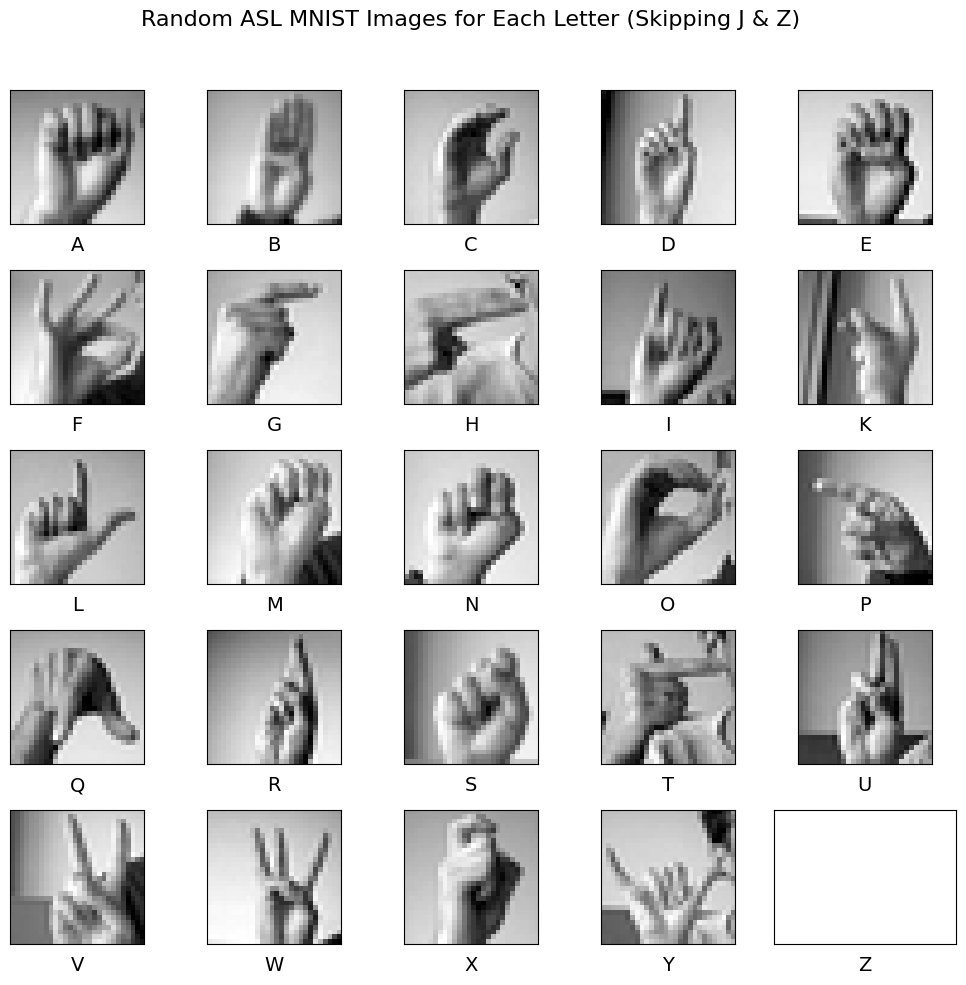

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def visualize_all_asl_letters(df):
    """
    Selects and visualizes a random ASL MNIST image for each letter (A-Y, excluding J and Z),
    keeping the letter labels at the bottom of each image.
    
    Parameters:
        df (pd.DataFrame): The ASL MNIST dataset, where the first column is 'label' 
                           and the rest are pixel values (28x28 image).
    """
    # Set up a 5x5 grid for visualization (24 letters)
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    fig.suptitle("Random ASL MNIST Images for Each Letter (Skipping J & Z)", fontsize=16)

    # Iterate through dataset labels (0-23), correctly skipping J (9) and Z (23)
    for i, ax in enumerate(axes.flat):
        label = i  # The dataset label

        # Skip 'J' (9) and 'Z' (23)
        asl_letter = chr(label + 65) if label < 9 else chr(label + 66)

        # Filter dataset for images of this label
        class_images = df[df['label'] == label]

        if class_images.empty:
            ax.set_xticks([])  # Remove axes
            ax.set_yticks([])
            ax.text(0.5, -0.2, asl_letter, size=14, ha='center', transform=ax.transAxes)
            continue

        # Select a random image
        random_index = np.random.randint(0, len(class_images))
        image = class_images.iloc[random_index, 1:].values.reshape(28, 28)

        # Display the image
        ax.imshow(image, cmap='gray')
        ax.set_xticks([])  # Remove x-axis
        ax.set_yticks([])  # Remove y-axis

        # Keep the letter at the bottom
        ax.text(0.5, -0.2, asl_letter, size=14, ha='center', transform=ax.transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
visualize_all_asl_letters(Train)

In [ ]:
Test.head()